# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')


In [2]:
data = pd.read_csv('data_pufas_5.csv',encoding='utf-8')

In [3]:
#Transform the data into a dataframe
df = pd.DataFrame(data)

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              58 non-null     str    
 1   Strain               52 non-null     str    
 2   Condition            58 non-null     str    
 3   Compound             58 non-null     str    
 4   ELOVL6               58 non-null     int64  
 5   HSD17B12             58 non-null     int64  
 6   fabD                 58 non-null     int64  
 7   fabI                 58 non-null     int64  
 8   ACSL                 58 non-null     int64  
 9   K10203_ELOVL6_TPM    58 non-null     float64
 10  K10251_HSD17B12_TPM  58 non-null     float64
 11  K00645_fabD_TPM      58 non-null     float64
 12  K00208_fabI_TPM      58 non-null     float64
 13  K01897_ACSL_TPM      58 non-null     float64
 14  Label                58 non-null     str    
dtypes: float64(5), int64(5), str(5)
memory usage: 10.1 KB

In [5]:
df['Species'].value_counts()

Species
Nannochloropsis oceanica     31
Phaeodactylum tricornutum    18
Nannochloropsis sp.           9
Name: count, dtype: int64

# Data Preparation

## 1.Handle Null data

In [6]:
#Check for missing values
print(df.isnull().sum())

Species                0
Strain                 6
Condition              0
Compound               0
ELOVL6                 0
HSD17B12               0
fabD                   0
fabI                   0
ACSL                   0
K10203_ELOVL6_TPM      0
K10251_HSD17B12_TPM    0
K00645_fabD_TPM        0
K00208_fabI_TPM        0
K01897_ACSL_TPM        0
Label                  0
dtype: int64


In [7]:
null_rows = df[df['Label'].isnull()]
print(null_rows)

Empty DataFrame
Columns: [Species, Strain, Condition, Compound, ELOVL6, HSD17B12, fabD, fabI, ACSL, K10203_ELOVL6_TPM, K10251_HSD17B12_TPM, K00645_fabD_TPM, K00208_fabI_TPM, K01897_ACSL_TPM, Label]
Index: []


In [8]:
# Drop rows with null values in the Label column
df = df.dropna(subset=['Label'])

In [9]:
# Fill missing values in the Strain column with 'Unknown'
df['Strain'] = df['Strain'].fillna('Unknown')
print("Missing values in Strain:", df['Strain'].isnull().sum())

Missing values in Strain: 0


In [10]:
null_rows = df[df['K01897_ACSL_TPM'].isnull()]
print(null_rows)

Empty DataFrame
Columns: [Species, Strain, Condition, Compound, ELOVL6, HSD17B12, fabD, fabI, ACSL, K10203_ELOVL6_TPM, K10251_HSD17B12_TPM, K00645_fabD_TPM, K00208_fabI_TPM, K01897_ACSL_TPM, Label]
Index: []


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              58 non-null     str    
 1   Strain               58 non-null     str    
 2   Condition            58 non-null     str    
 3   Compound             58 non-null     str    
 4   ELOVL6               58 non-null     int64  
 5   HSD17B12             58 non-null     int64  
 6   fabD                 58 non-null     int64  
 7   fabI                 58 non-null     int64  
 8   ACSL                 58 non-null     int64  
 9   K10203_ELOVL6_TPM    58 non-null     float64
 10  K10251_HSD17B12_TPM  58 non-null     float64
 11  K00645_fabD_TPM      58 non-null     float64
 12  K00208_fabI_TPM      58 non-null     float64
 13  K01897_ACSL_TPM      58 non-null     float64
 14  Label                58 non-null     str    
dtypes: float64(5), int64(5), str(5)
memory usage: 10.2 KB

## 2.Cleaning data

In [12]:
#Cleaning categorical columns by removing newline characters and stripping whitespace
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].str.replace('\n', '', regex=False).str.strip()

In [13]:
df.head()

,Species,Strain,Condition,Compound,ELOVL6,HSD17B12,fabD,fabI,ACSL,K10203_ELOVL6_TPM,K10251_HSD17B12_TPM,K00645_fabD_TPM,K00208_fabI_TPM,K01897_ACSL_TPM,Label
0,Nannochloropsis sp.,PJ12,Phosphorus,EPA (PUFAs),1,1,1,1,1,2917.22,376.30,309.16,276.34,538.29,Medium
1,Nannochloropsis sp.,PJ12,Phosphorus,EPA (PUFAs),1,1,1,1,1,2797.00,366.24,321.59,278.35,532.15,Medium
2,Nannochloropsis sp.,PJ12,Phosphorus,EPA (PUFAs),1,1,1,1,1,2830.90,367.86,312.34,281.89,534.16,Low
3,Nannochloropsis sp.,PJ12,Phosphorus,EPA (PUFAs),1,1,1,1,1,2246.41,315.46,182.33,313.27,722.86,Medium
4,Nannochloropsis sp.,PJ12,Phosphorus,EPA (PUFAs),1,1,1,1,1,2173.34,309.38,191.45,326.23,738.53,Medium


In [14]:
df['Condition'].value_counts()

Condition
Phosphorus    24
Light         16
Nitrogen      12
Genotype       6
Name: count, dtype: int64

# EDA

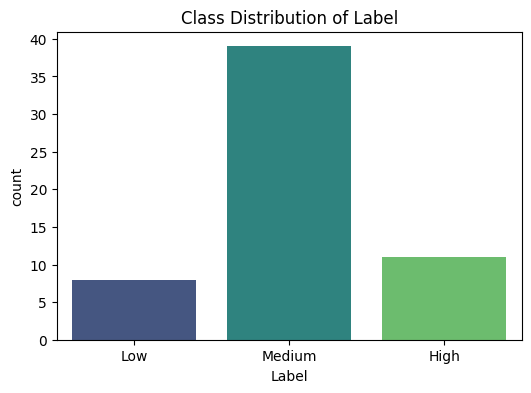

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label', order=['Low', 'Medium', 'High'],palette='viridis')
plt.title('Class Distribution of Label')
plt.show()

In [16]:
df['Label'].value_counts()

Label
Medium    39
High      11
Low        8
Name: count, dtype: int64

พบยีนทั้งหมด 5 ตัว ได้แก่: ['K10203_ELOVL6_TPM', 'K10251_HSD17B12_TPM', 'K00645_fabD_TPM', 'K00208_fabI_TPM', 'K01897_ACSL_TPM']


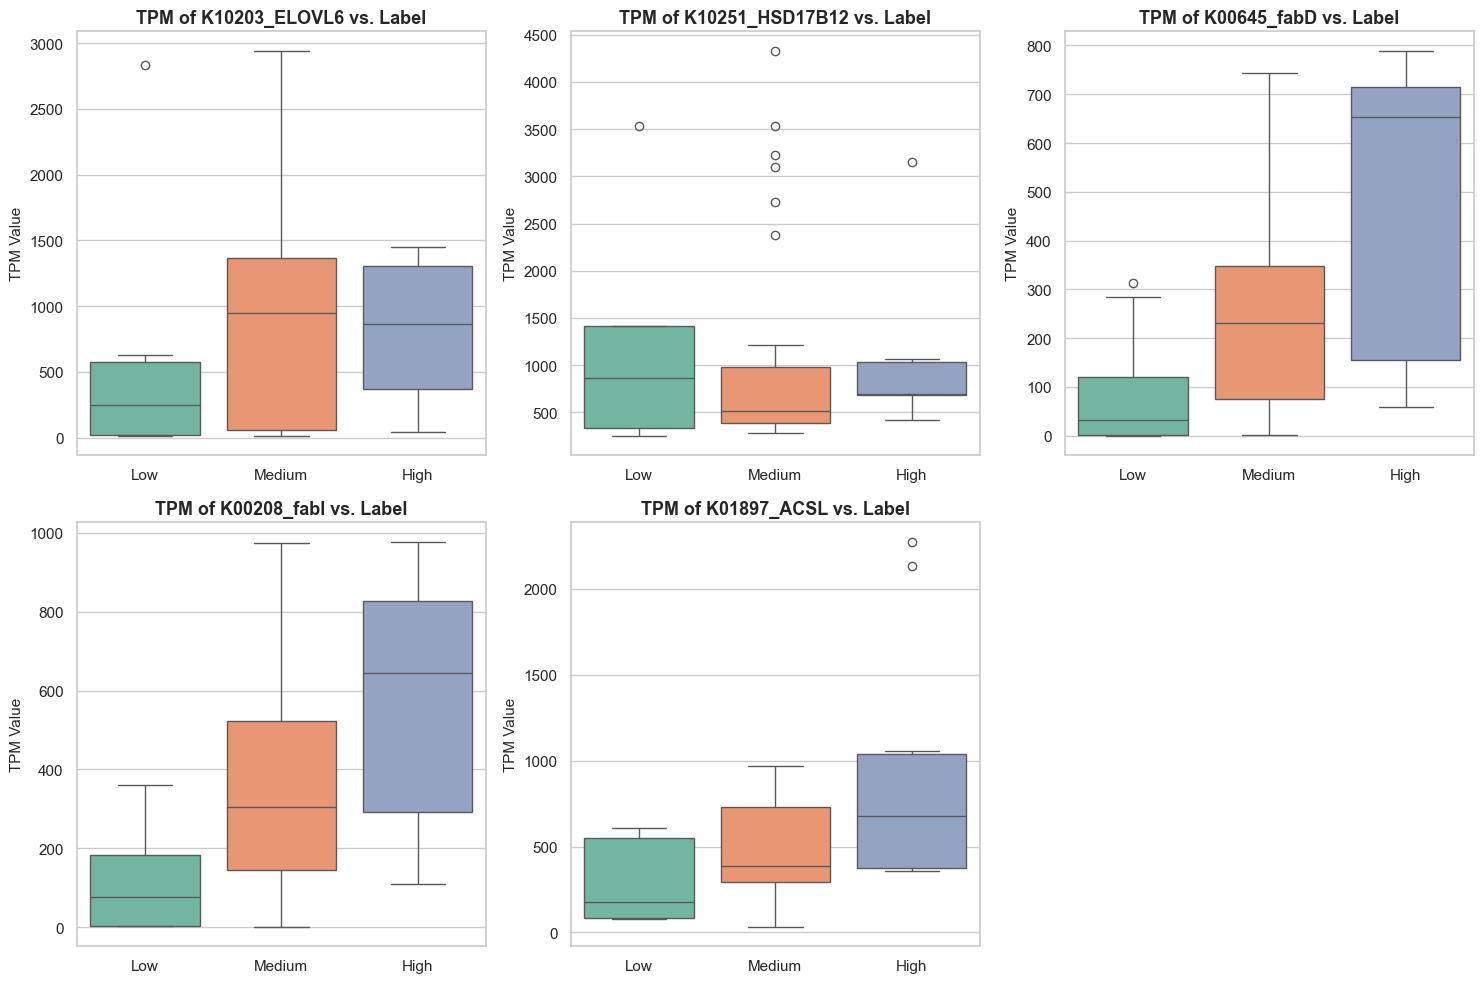

In [17]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

tpm_cols = [col for col in df.columns if '_TPM' in col]
num_genes = len(tpm_cols)

print(f"พบยีนทั้งหมด {num_genes} ตัว ได้แก่: {tpm_cols}")


cols_per_row = 3
rows = math.ceil(num_genes / cols_per_row)


fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))

axes = axes.flatten()


for i, col_name in enumerate(tpm_cols):
    # วาด Boxplot ลงในช่องที่ i
    sns.boxplot(
        data=df,
        x='Label',
        y=col_name,
        order=['Low', 'Medium', 'High'],
        ax=axes[i],
        palette='Set2' # เปลี่ยนสีได้ เช่น 'Set3', 'viridis', 'coolwarm'
    )

    # ตัดคำว่า '_TPM' ออกจากชื่อบนหัวกราฟเพื่อความสวยงาม
    gene_name = col_name.replace('_TPM', '')

    # ตั้งชื่อหัวกราฟและแกน Y
    axes[i].set_title(f'TPM of {gene_name} vs. Label', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('TPM Value', fontsize=11)
    axes[i].set_xlabel('')


for j in range(num_genes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Heat Map shows relation between each gene expression

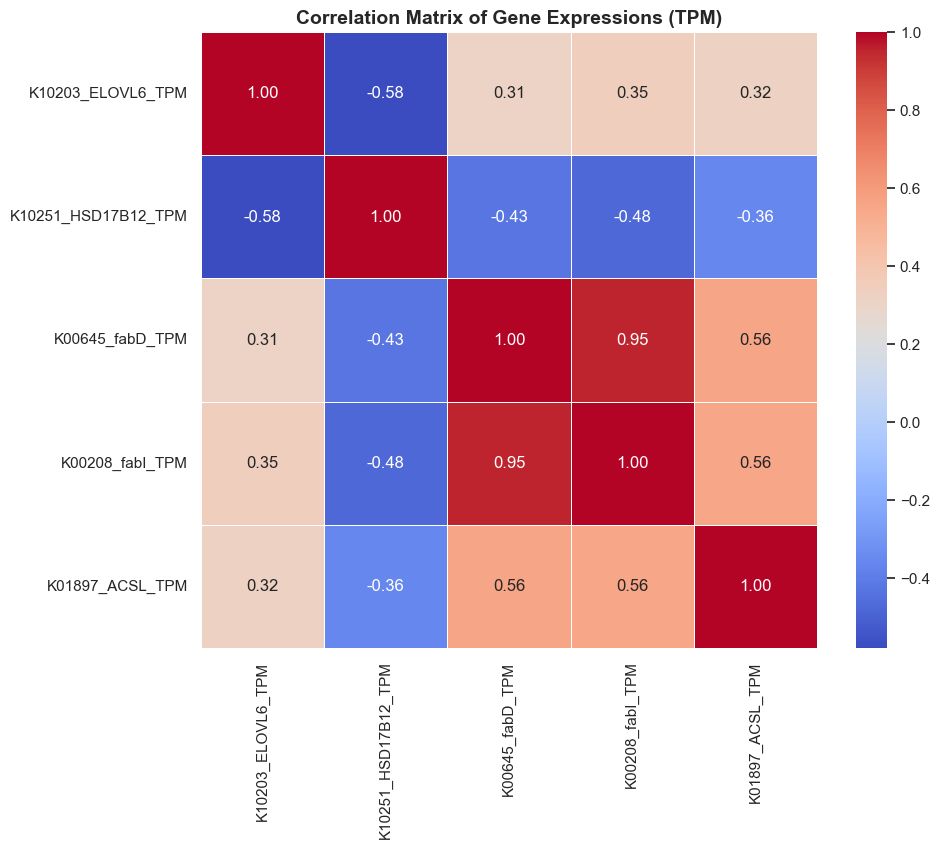

In [18]:
# เลือกเฉพาะคอลัมน์ที่ลงท้ายด้วย _TPM
tpm_cols = [col for col in df.columns if '_TPM' in col]

plt.figure(figsize=(10, 8))
corr_matrix = df[tpm_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Gene Expressions (TPM)', fontsize=14, fontweight='bold')
plt.show()

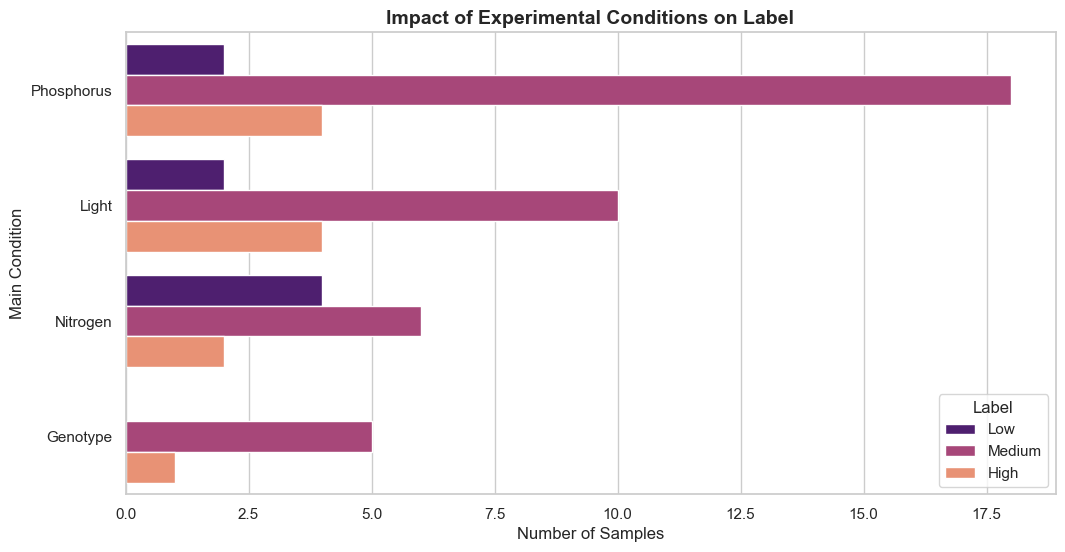

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Condition', hue='Label', hue_order=['Low', 'Medium', 'High'], palette='magma')
plt.title('Impact of Experimental Conditions on Label', fontsize=14, fontweight='bold')
plt.xlabel('Number of Samples')
plt.ylabel('Main Condition')
plt.legend(title='Label', loc='lower right')
plt.show()

# Data Preprocessing

## 1.Feature Selection

In [20]:
# Define the target column
target_col = 'Label'
# Delete unnecessary columns
cols_to_drop = ['Strain']
df = df.drop(columns=cols_to_drop)

X = df

## 2.Seperate taget columns

In [21]:
#Separate X and Y
X = X.drop(columns=[target_col])
Y = df[target_col]

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              58 non-null     str    
 1   Condition            58 non-null     str    
 2   Compound             58 non-null     str    
 3   ELOVL6               58 non-null     int64  
 4   HSD17B12             58 non-null     int64  
 5   fabD                 58 non-null     int64  
 6   fabI                 58 non-null     int64  
 7   ACSL                 58 non-null     int64  
 8   K10203_ELOVL6_TPM    58 non-null     float64
 9   K10251_HSD17B12_TPM  58 non-null     float64
 10  K00645_fabD_TPM      58 non-null     float64
 11  K00208_fabI_TPM      58 non-null     float64
 12  K01897_ACSL_TPM      58 non-null     float64
 13  Label                58 non-null     str    
dtypes: float64(5), int64(5), str(4)
memory usage: 9.4 KB


## 3. Encoding

### One-Hot Encoding

In [23]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [24]:
X_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ELOVL6                             58 non-null     int64  
 1   HSD17B12                           58 non-null     int64  
 2   fabD                               58 non-null     int64  
 3   fabI                               58 non-null     int64  
 4   ACSL                               58 non-null     int64  
 5   K10203_ELOVL6_TPM                  58 non-null     float64
 6   K10251_HSD17B12_TPM                58 non-null     float64
 7   K00645_fabD_TPM                    58 non-null     float64
 8   K00208_fabI_TPM                    58 non-null     float64
 9   K01897_ACSL_TPM                    58 non-null     float64
 10  Species_Nannochloropsis sp.        58 non-null     bool   
 11  Species_Phaeodactylum tricornutum  58 non-null     bool   
 12  Conditi

### Label Encoder

In [25]:
# To change Label(High,Medium,Low) to numerical values (0,1,2)
label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)

print(f"Label classes: {label_encoder.classes_}")
print(f"Encoded labels: {np.unique(Y_encoded)}")

Label classes: ['High' 'Low' 'Medium']
Encoded labels: [0 1 2]


## 4.Train Test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, Y_encoded, test_size=0.3, random_state=42, stratify=Y_encoded
)

In [27]:
import os
# FIX 1: Set environment variable BEFORE importing sklearn/scipy
os.environ["SCIPY_ARRAY_API"] = "1"

import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# --- Setup and Initial State ---
print(f"Original dataset shape: {Counter(Y_encoded)}")
initial_counts = Counter(Y_encoded)
fixed_target_count = 30

low_label = label_encoder.transform(['Low'])[0]
medium_label = label_encoder.transform(['Medium'])[0]
high_label = label_encoder.transform(['High'])[0]

# --- Step 1: Oversampling ---
# FIX 2: Only include classes in ROS that are currently BELOW the target.
# If you include a class that is already at 100 in RandomOverSampler 
# and set its strategy to 100, it can sometimes trigger validation errors.
ros_strategy = {
    label: fixed_target_count 
    for label, count in initial_counts.items() 
    if count < fixed_target_count
}

if ros_strategy:
    ros = RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)
    X_resampled_over, Y_resampled_over = ros.fit_resample(X_encoded, Y_encoded)
else:
    X_resampled_over, Y_resampled_over = X_encoded, Y_encoded

print(f"Dataset shape after oversampling: {Counter(Y_resampled_over)}")

# --- Step 2: Undersampling ---
# Now that all classes are >= fixed_target_count, we bring them all down to exactly 30.
rus_strategy = {
    low_label: fixed_target_count,
    medium_label: fixed_target_count,
    high_label: fixed_target_count
}

rus = RandomUnderSampler(sampling_strategy=rus_strategy, random_state=42)
X_resampled_final, Y_resampled_final = rus.fit_resample(X_resampled_over, Y_resampled_over)

print(f"Dataset shape after combined sampling: {Counter(Y_resampled_final)}")

# --- Final Conversion ---
X_balanced = pd.DataFrame(X_resampled_final, columns=X_encoded.columns)
Y_balanced = pd.Series(Y_resampled_final)

print(f"\nClass distribution after balancing (decoded labels):")
balanced_labels = label_encoder.inverse_transform(Y_balanced)
print(pd.Series(balanced_labels).value_counts())

Original dataset shape: Counter({2: 39, 0: 11, 1: 8})
Dataset shape after oversampling: Counter({2: 39, 1: 30, 0: 30})
Dataset shape after combined sampling: Counter({0: 30, 1: 30, 2: 30})

Class distribution after balancing (decoded labels):
High      30
Low       30
Medium    30
Name: count, dtype: int64


## 5. Data scaling

In [28]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")

X_train shape: (40, 18), X_test shape: (18, 18)


# Model

## Import Model

In [29]:
# Model training for multiple classifiers: LogisticRegression, QDA, KNN, ANN, SVC, RandomForest, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC    # ->SVM
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

# Keras / TensorFlow for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## Model Trainning

In [30]:
# reproducibility
np.random.seed(42)
tf.random.set_seed(42)


n_classes = len(np.unique(y_train))

results = {}

### Logistic Regression

In [31]:
# 1) Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=2000)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results['LogisticRegression'] = {
    'model': lr,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,matthews_corrcoef

# Base logistic regression (multiclass)
lr = LogisticRegression(random_state=42,class_weight='balanced', max_iter=1000)

# Parameter grid with solver-safe combinations
param_grid = [
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'multi_class': ['multinomial'],
        'max_iter': [1000]
    },
    {
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'multi_class': ['ovr'],
        'max_iter': [1000]
    }
]

# Grid search
lr_grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
print("Best params:", lr_grid.best_params_)
print("Best CV score:", lr_grid.best_score_)

# Test evaluation
y_pred = best_lr.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_lr, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

results['LogisticRegression'] = {
    'model': best_lr,  # เก็บ best_lr ที่ผ่านการจูนแล้ว 
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True),
    'best_params': lr_grid.best_params_,  # เก็บพารามิเตอร์ที่ดีที่สุดไว้ดู
    'cv_mean_score': cv_scores.mean()     # เก็บค่า CV Score ไว้เปรียบเทียบ
}


#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test, y_pred)    
macro_f1 = results['LogisticRegression']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression'].get('best_cv_score', results['LogisticRegression'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 

Fitting 5 folds for each of 38 candidates, totalling 190 fits
Best params: {'C': 1, 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l1', 'solver': 'liblinear'}
Best CV score: 0.6
Test Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.67      0.44         3
           1       1.00      0.67      0.80         3
           2       0.80      0.67      0.73        12

    accuracy                           0.67        18
   macro avg       0.71      0.67      0.66        18
weighted avg       0.76      0.67      0.69        18

Confusion Matrix:
 [[2 0 1]
 [0 2 1]
 [4 0 8]]
Train CV scores: [0.625 0.75  0.75  0.375 0.5  ]
Train CV mean: 0.6
   - Test MCC Score      : 0.4170 


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,matthews_corrcoef

# Base logistic regression (multiclass)
lr = LogisticRegression(random_state=42, class_weight='balanced')

# Parameter grid with solver-safe combinations
param_grid = [
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'multi_class': ['multinomial'],
        'max_iter': [1000]
    },
    {
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'multi_class': ['ovr'],
        'max_iter': [1000]
    }
]

# Grid search
lr_grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
print("Best params:", lr_grid.best_params_)
print("Best CV score:", lr_grid.best_score_)

# Test evaluation
y_pred = best_lr.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_lr, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test, y_pred)    
macro_f1 = results['LogisticRegression']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression'].get('best_cv_score', results['LogisticRegression'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 

Fitting 5 folds for each of 38 candidates, totalling 190 fits
Best params: {'C': 1, 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l1', 'solver': 'liblinear'}
Best CV score: 0.6
Test Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.67      0.44         3
           1       1.00      0.67      0.80         3
           2       0.80      0.67      0.73        12

    accuracy                           0.67        18
   macro avg       0.71      0.67      0.66        18
weighted avg       0.76      0.67      0.69        18

Confusion Matrix:
 [[2 0 1]
 [0 2 1]
 [4 0 8]]
Train CV scores: [0.625 0.75  0.75  0.375 0.5  ]
Train CV mean: 0.6
   - Test MCC Score      : 0.4170 


### Retraining Logistic Regression with Balanced Data

In [35]:
# Split the balanced data into training and testing sets
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(
    X_balanced, Y_balanced, test_size=0.3, random_state=42, stratify=Y_balanced
)

# Scale the balanced data
scaler_balanced = StandardScaler()
X_train_balanced_scaled = scaler_balanced.fit_transform(X_train_balanced)
X_test_balanced_scaled = scaler_balanced.transform(X_test_balanced)

print(f"X_train_balanced shape: {X_train_balanced_scaled.shape}, X_test_balanced shape: {X_test_balanced_scaled.shape}")

X_train_balanced shape: (63, 18), X_test_balanced shape: (27, 18)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,matthews_corrcoef
# Retrain Logistic Regression with balanced and scaled data
# Using the best parameters found earlier for Logistic Regression
lr_balanced = LogisticRegression(**lr_grid.best_params_, random_state=42)
lr_balanced.fit(X_train_balanced_scaled, y_train_balanced)

y_pred_balanced = lr_balanced.predict(X_test_balanced_scaled)

print("\n--- Logistic Regression with Balanced Data ---")
print("Test Accuracy (Balanced Data):", accuracy_score(y_test_balanced, y_pred_balanced))
print("\nClassification Report (Balanced Data):\n", classification_report(y_test_balanced, y_pred_balanced))
print("Confusion Matrix (Balanced Data):\n", confusion_matrix(y_test_balanced, y_pred_balanced))

# Store results for the balanced model
results['LogisticRegression_Balanced'] = {
    'model': lr_balanced,
    'accuracy': accuracy_score(y_test_balanced, y_pred_balanced),
    'report': classification_report(y_test_balanced, y_pred_balanced, output_dict=True)
}

#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test_balanced, y_pred_balanced)
macro_f1 = results['LogisticRegression_Balanced']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression_Balanced'].get('best_cv_score', results['LogisticRegression_Balanced'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 


--- Logistic Regression with Balanced Data ---
Test Accuracy (Balanced Data): 0.6296296296296297

Classification Report (Balanced Data):
               precision    recall  f1-score   support

           0       0.80      0.89      0.84         9
           1       0.57      0.89      0.70         9
           2       0.33      0.11      0.17         9

    accuracy                           0.63        27
   macro avg       0.57      0.63      0.57        27
weighted avg       0.57      0.63      0.57        27

Confusion Matrix (Balanced Data):
 [[8 0 1]
 [0 8 1]
 [2 6 1]]
   - Test MCC Score      : 0.4758 


### SMOTE: Balancing with Synthetic Data Generation
This approach creates new samples that look like the original data by interpolating between neighbors.

In [38]:
from imblearn.over_sampling import SMOTE

# 1. Use the original imbalanced split to ensure the test set is 'Real'
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, Y_encoded, test_size=0.3, random_state=42, stratify=Y_encoded
)

# 2. Apply SMOTE only to the Training set
# This creates synthetic examples that 'blend' the original features
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training shape:", Counter(y_train))
print("Balanced training shape (SMOTE):", Counter(y_train_smote))

# 3. Scale based on the new balanced training set
scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_smote_scaled = scaler_smote.transform(X_test)

Original training shape: Counter({2: 27, 0: 8, 1: 5})
Balanced training shape (SMOTE): Counter({2: 27, 0: 27, 1: 27})


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,matthews_corrcoef
# Retrain Logistic Regression on SMOTE data
lr_smote = LogisticRegression(**lr_grid.best_params_, random_state=42)
lr_smote.fit(X_train_smote_scaled, y_train_smote)

y_pred_smote = lr_smote.predict(X_test_smote_scaled)

print("\n--- Logistic Regression with SMOTE Balanced Training Data ---")
print("Test Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_smote))

# Store results
results['LogisticRegression_SMOTE'] = {
    'model': lr_smote,
    'accuracy': accuracy_score(y_test, y_pred_smote),
    'report': classification_report(y_test, y_pred_smote, output_dict=True)
}


#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test, y_pred_smote)    
macro_f1 = results['LogisticRegression_SMOTE']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression_SMOTE'].get('best_cv_score', results['LogisticRegression_SMOTE'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 


--- Logistic Regression with SMOTE Balanced Training Data ---
Test Accuracy: 0.6111111111111112

Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.33      0.25         3
           1       1.00      0.67      0.80         3
           2       0.73      0.67      0.70        12

    accuracy                           0.61        18
   macro avg       0.64      0.56      0.58        18
weighted avg       0.68      0.61      0.64        18

Confusion Matrix:
 [[1 0 2]
 [0 2 1]
 [4 0 8]]
   - Test MCC Score      : 0.2680 


### SVC with SMOTE Balancing

In [ ]:
# 1. First, find best parameters for SVC using the original scaled data
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc = SVC(probability=True, random_state=42)
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

svc_grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
svc_grid.fit(X_train_scaled, y_train)

# 2. Now initialize SVC with those best parameters for the SMOTE data
svc_smote = SVC(**svc_grid.best_params_, probability=True, random_state=42)

# Train on SMOTE-balanced data
svc_smote.fit(X_train_smote_scaled, y_train_smote)

# Predict on the original test set (using SMOTE-specific scaling)
y_pred_svc_smote = svc_smote.predict(X_test_smote_scaled)

print("--- SVC with SMOTE Balanced Training Data ---")
print("Best Params used:", svc_grid.best_params_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_svc_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc_smote))

# Store results
results['SVC_SMOTE'] = {
    'model': svc_smote,
    'accuracy': accuracy_score(y_test, y_pred_svc_smote),
    'report': classification_report(y_test, y_pred_svc_smote, output_dict=True)
}

#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test, y_pred)    
macro_f1 = results['LogisticRegression']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression'].get('best_cv_score', results['LogisticRegression'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 

--- SVC with SMOTE Balanced Training Data ---
Best Params used: {'C': 10, 'gamma': 'auto', 'kernel': 'poly'}
Test Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.67      0.44         3
           1       1.00      0.67      0.80         3
           2       0.80      0.67      0.73        12

    accuracy                           0.67        18
   macro avg       0.71      0.67      0.66        18
weighted avg       0.76      0.67      0.69        18

Confusion Matrix:
 [[2 0 1]
 [0 2 1]
 [4 0 8]]


In [ ]:
from sklearn.metrics import classification_report

# Compare Original SVC (if exists) vs SMOTE SVC
print("=== Original SVM Performance ===")
if 'SVC' in results:
    y_pred_orig = results['SVC']['model'].predict(X_test_scaled)
    print(classification_report(y_test, y_pred_orig))
else:
    print("Original SVM results not found.")

print("\n=== SMOTE-Balanced SVM Performance ===")
if 'SVC_SMOTE' in results:
    print(classification_report(y_test, y_pred_svc_smote))
else:
    print("SMOTE SVM results not found.")

=== Original SVM Performance ===
Original SVM results not found.

=== SMOTE-Balanced SVM Performance ===
              precision    recall  f1-score   support

           0       0.33      0.67      0.44         3
           1       1.00      0.67      0.80         3
           2       0.80      0.67      0.73        12

    accuracy                           0.67        18
   macro avg       0.71      0.67      0.66        18
weighted avg       0.76      0.67      0.69        18



# 4) Support Vector Classifier
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)
results['SVC'] = {
    'model': svc,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}


In [ ]:
# 4) Support Vector Classifier
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)
results['SVC'] = {
    'model': svc,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}


In [40]:
# ...existing code...
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,matthews_corrcoef

# Define base SVC and hyperparameter grid
svc = SVC(probability=True, random_state=42)
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

# Grid search with 5-fold CV
svc_grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
svc_grid.fit(X_train_scaled, y_train)

# Best estimator and CV score
best_svc = svc_grid.best_estimator_
print("Best params:", svc_grid.best_params_)
print("Best CV score:", svc_grid.best_score_)

# Evaluate on test set
y_pred = best_svc.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_svc, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test, y_pred)    
macro_f1 = results['LogisticRegression']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression'].get('best_cv_score', results['LogisticRegression'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'poly'}
Best CV score: 0.725
Test Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.00      0.00      0.00         3
           2       0.69      0.92      0.79        12

    accuracy                           0.67        18
   macro avg       0.40      0.42      0.40        18
weighted avg       0.54      0.67      0.59        18

Confusion Matrix:
 [[ 1  0  2]
 [ 0  0  3]
 [ 1  0 11]]
Train CV scores: [0.75  0.75  0.875 0.625 0.625]
Train CV mean: 0.725
   - Test MCC Score      : 0.1768 


### QDA

In [ ]:
# 2) Quadratic Discriminant Analysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)
y_pred = qda.predict(X_test_scaled)
results['QDA'] = {
    'model': qda,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [ ]:
# ...existing code...
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base QDA
qda = QuadraticDiscriminantAnalysis()

# Parameter grid (regularization + optional covariance storage / tolerance)
param_grid = {
    'reg_param': [0.0, 0.001, 0.01, 0.1, 0.5],
    'store_covariance': [False, True],
    'tol': [1e-4, 1e-3, 1e-2]
}

# Grid search with 5-fold CV
qda_grid = GridSearchCV(qda, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
qda_grid.fit(X_train_scaled, y_train)

best_qda = qda_grid.best_estimator_
print("Best params:", qda_grid.best_params_)
print("Best CV score:", qda_grid.best_score_)

# Evaluate on test set
y_pred = best_qda.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_qda, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'reg_param': 0.01, 'store_covariance': False, 'tol': 0.0001}
Best CV score: 0.6955555555555555
Test Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         2
           2       0.67      1.00      0.80         8

    accuracy                           0.67        12
   macro avg       0.22      0.33      0.27        12
weighted avg       0.44      0.67      0.53        12

Confusion Matrix:
 [[0 0 2]
 [0 0 2]
 [0 0 8]]
Train CV scores: [0.7        0.66666667 0.88888889 0.55555556 0.66666667]
Train CV mean: 0.6955555555555555


In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV

# 1. Grid Search for QDA on original scaled data if not already done
qda = QuadraticDiscriminantAnalysis()
param_grid_qda = {
    'reg_param': [0.0, 0.001, 0.01, 0.1, 0.5]
}
qda_grid = GridSearchCV(qda, param_grid_qda, cv=5, scoring='accuracy', n_jobs=-1)
qda_grid.fit(X_train_scaled, y_train)

# 2. Initialize QDA with the best regularization parameter
best_reg_param = qda_grid.best_params_.get('reg_param', 0.01)
qda_smote = QuadraticDiscriminantAnalysis(reg_param=best_reg_param)

# 3. Train on SMOTE-balanced data
qda_smote.fit(X_train_smote_scaled, y_train_smote)

# 4. Predict on the original test set
y_pred_qda_smote = qda_smote.predict(X_test_smote_scaled)

print("--- QDA with SMOTE Balanced Training Data ---")
print(f"Using reg_param: {best_reg_param}")
print("Test Accuracy:", accuracy_score(y_test, y_pred_qda_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_qda_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_qda_smote))

# Store results
results['QDA_SMOTE'] = {
    'model': qda_smote,
    'accuracy': accuracy_score(y_test, y_pred_qda_smote),
    'report': classification_report(y_test, y_pred_qda_smote, output_dict=True)
}

--- QDA with SMOTE Balanced Training Data ---
Using reg_param: 0.01
Test Accuracy: 0.7222222222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.67      0.67      0.67         3
           2       0.82      0.75      0.78        12

    accuracy                           0.72        18
   macro avg       0.66      0.69      0.67        18
weighted avg       0.74      0.72      0.73        18

Confusion Matrix:
 [[2 0 1]
 [0 2 1]
 [2 1 9]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. Find best parameters for KNN using original scaled training data
knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
knn_grid = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

# 2. Initialize KNN with best params
best_knn_params = knn_grid.best_params_
knn_smote = KNeighborsClassifier(**best_knn_params)

# 3. Train on SMOTE-balanced data
knn_smote.fit(X_train_smote_scaled, y_train_smote)

# 4. Evaluate on original test set
y_pred_knn_smote = knn_smote.predict(X_test_smote_scaled)

print("--- KNN with SMOTE Balanced Training Data ---")
print(f"Best Params: {best_knn_params}")
print("Test Accuracy:", accuracy_score(y_test, y_pred_knn_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn_smote))

# Store results
results['KNN_SMOTE'] = {
    'model': knn_smote,
    'accuracy': accuracy_score(y_test, y_pred_knn_smote),
    'report': classification_report(y_test, y_pred_knn_smote, output_dict=True)
}

--- KNN with SMOTE Balanced Training Data ---
Best Params: {'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
Test Accuracy: 0.6111111111111112

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.33      0.29         3
           1       0.67      0.67      0.67         3
           2       0.73      0.67      0.70        12

    accuracy                           0.61        18
   macro avg       0.55      0.56      0.55        18
weighted avg       0.64      0.61      0.62        18



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Hyperparameter Tuning for Random Forest on original scaled training data
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

# 2. Initialize and Train with SMOTE data using best params
best_rf_params = rf_grid.best_params_
rf_smote = RandomForestClassifier(**best_rf_params, random_state=42)
rf_smote.fit(X_train_smote_scaled, y_train_smote)

# 3. Evaluate on the original imbalanced test set
y_pred_rf_smote = rf_smote.predict(X_test_smote_scaled)

print("--- Random Forest with SMOTE Balanced Training Data ---")
print(f"Best Params: {best_rf_params}")
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_smote))

# Store results
results['RandomForest_SMOTE'] = {
    'model': rf_smote,
    'accuracy': accuracy_score(y_test, y_pred_rf_smote),
    'report': classification_report(y_test, y_pred_rf_smote, output_dict=True)
}

--- Random Forest with SMOTE Balanced Training Data ---
Best Params: {'class_weight': None, 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Test Accuracy: 0.7777777777777778

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       1.00      0.67      0.80         3
           2       0.83      0.83      0.83        12

    accuracy                           0.78        18
   macro avg       0.78      0.72      0.73        18
weighted avg       0.81      0.78      0.78        18

Confusion Matrix:
 [[ 2  0  1]
 [ 0  2  1]
 [ 2  0 10]]


### KNN

In [ ]:
# 3) K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
results['KNN'] = {
    'model': knn,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,matthews_corrcoef

# Base KNN
knn = KNeighborsClassifier()

# Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

# Grid search with 5-fold CV
knn_grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_
print("Best params:", knn_grid.best_params_)
print("Best CV score:", knn_grid.best_score_)

# Evaluate on test set
y_pred = best_knn.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test, y_pred)    
macro_f1 = results['LogisticRegression']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression'].get('best_cv_score', results['LogisticRegression'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'algorithm': 'auto', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
Best CV score: 0.675
Test Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         3
           2       0.67      1.00      0.80        12

    accuracy                           0.67        18
   macro avg       0.22      0.33      0.27        18
weighted avg       0.44      0.67      0.53        18

Confusion Matrix:
 [[ 0  0  3]
 [ 0  0  3]
 [ 0  0 12]]
Train CV scores: [0.75  0.75  0.625 0.625 0.625]
Train CV mean: 0.675
   - Test MCC Score      : 0.0000 


### Random Forest

In [ ]:
# 5) Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
results['RandomForest'] = {
    'model': rf,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [43]:
# ...existing code...
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,matthews_corrcoef

# Base Random Forest
rf = RandomForestClassifier(random_state=42,class_weight='balanced')

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Grid search with 5-fold CV
rf_grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
print("Best params:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

# Evaluate on test set
y_pred = best_rf.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test, y_pred)    
macro_f1 = results['LogisticRegression']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression'].get('best_cv_score', results['LogisticRegression'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best params: {'bootstrap': True, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.725
Test Accuracy: 0.7777777777777778

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.67      0.67      0.67         3
           2       0.83      0.83      0.83        12

    accuracy                           0.78        18
   macro avg       0.72      0.72      0.72        18
weighted avg       0.78      0.78      0.78        18

Confusion Matrix:
 [[ 2  0  1]
 [ 0  2  1]
 [ 1  1 10]]
Train CV scores: [0.625 0.875 0.875 0.5   0.75 ]
Train CV mean: 0.725
   - Test MCC Score      : 0.5556 


### XGBoost

In [ ]:
# 6) XGBoost
xgb = XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)
results['XGBoost'] = {
    'model': xgb,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [44]:
# ...existing code...
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,matthews_corrcoef

# Base XGBoost (multiclass)
xgb = XGBClassifier(objective='multi:softprob', use_label_encoder=False,
                    eval_metric='mlogloss', random_state=42, n_jobs=-1,class_weight='balanced')

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5],
    'min_child_weight': [1, 3, 5]
}

# Grid search with 5-fold CV
xgb_grid = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_scaled, y_train)

best_xgb = xgb_grid.best_estimator_
print("Best params:", xgb_grid.best_params_)
print("Best CV score:", xgb_grid.best_score_)

# Evaluate on test set
y_pred = best_xgb.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_xgb, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test, y_pred)    
macro_f1 = results['LogisticRegression']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression'].get('best_cv_score', results['LogisticRegression'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Best params: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV score: 0.775
Test Accuracy: 0.7777777777777778

Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         3
           2       0.79      0.92      0.85        12

    accuracy                           0.78        18
   macro avg       0.51      0.64      0.57        18
weighted avg       0.65      0.78      0.71        18

Confusion Matrix:
 [[ 3  0  0]
 [ 0  0  3]
 [ 1  0 11]]
Train CV scores: [0.75  0.75  1.    0.625 0.75 ]
Train CV mean: 0.775
   - Test MCC Score      : 0.5345 


### ANN

In [ ]:
# 7) ANN (Keras)
# Use one-hot for training labels
y_train_cat = to_categorical(y_train, num_classes=n_classes)  #One-hot แล้วววววววววว
y_test_cat = to_categorical(y_test, num_classes=n_classes)

ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
ann.fit(X_train_scaled, y_train_cat, validation_split=0.1, epochs=100, batch_size=32, callbacks=[es], verbose=0)

y_pred_proba = ann.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)
results['ANN'] = {
    'model': ann,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [45]:
# ANN tuning with Keras Tuner (no scikit-learn GridSearchCV)
# Installs: pip install -U keras-tuner (run externally if needed)
try:
    import keras_tuner as kt
except Exception as e:
    raise ImportError("Please install keras-tuner: pip install -U keras-tuner")
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,matthews_corrcoef
import numpy as np

def build_model(hp):
    units = hp.Choice('units', [64, 128])
    dropout = hp.Choice('dropout', [0.2, 0.3])
    lr = hp.Choice('learning_rate', [1e-3, 5e-4])
    model = keras.Sequential([
        keras.layers.Dense(units, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(max(32, units//2), activation='relu'),
        keras.layers.Dropout(dropout/2),
        keras.layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Random search tuner (fast and simple)
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=6,
                        executions_per_trial=1, directory='kt_dir', project_name='ann_tune')

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
tuner.search(X_train_scaled, y_train, epochs=50, validation_split=0.1, callbacks=[es], verbose=1)

# Best hyperparameters and best validation (used here as CV proxy)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_trials = tuner.oracle.get_best_trials(num_trials=1)
best_val = None
if best_trials:
    try:
        best_val = best_trials[0].metrics.get_last_value('val_accuracy')
    except Exception:
        best_val = None

print("Best params:", {
    'units': best_hps.get('units'),
    'dropout': best_hps.get('dropout'),
    'learning_rate': best_hps.get('learning_rate')
})
print("Best CV score:", best_val)

# Build and fit best model on full training set
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.1, callbacks=[es], verbose=0)

# Evaluate on test set
y_pred = np.argmax(best_model.predict(X_test_scaled), axis=1)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: manual cross-validated scores on training set (retrain per fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_idx, val_idx in skf.split(X_train_scaled, y_train):
    model = tuner.hypermodel.build(best_hps)
    model.fit(X_train_scaled[train_idx], y_train[train_idx], epochs=50,
              validation_data=(X_train_scaled[val_idx], y_train[val_idx]), callbacks=[es], verbose=0)
    preds = np.argmax(model.predict(X_train_scaled[val_idx]), axis=1)
    cv_scores.append(accuracy_score(y_train[val_idx], preds))

print("Train CV scores:", cv_scores)
print("Train CV mean:", np.mean(cv_scores))

#MCC Score Calculation
mcc_score = matthews_corrcoef(y_test, y_pred)    
macro_f1 = results['LogisticRegression']['report']['macro avg']['f1-score']
cv_score = results['LogisticRegression'].get('best_cv_score', results['LogisticRegression'].get('cv_mean_score', 'N/A'))
if isinstance(cv_score, float):
    cv_score_str = f"{cv_score:.4f}"
else:
    cv_score_str = str(cv_score)
        
        # --- แสดงค่า MCC ---
print(f"   - Test MCC Score      : {mcc_score:.4f} ") 

Trial 6 Complete [00h 00m 03s]
val_accuracy: 0.75

Best val_accuracy So Far: 0.75
Total elapsed time: 00h 00m 29s
Best params: {'units': 64, 'dropout': 0.3, 'learning_rate': 0.001}
Best CV score: 0.75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Test Accuracy: 0.5555555555555556

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         3
           2       0.62      0.83      0.71        12

    accuracy                           0.56        18
   macro avg       0.21      0.28      0.24        18
weighted avg       0.42      0.56      0.48        18

Confusion Matrix:
 [[ 0  0  3]
 [ 0  0  3]
 [ 2  0 10]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Train CV scores: [0.75, 0.75, 0.625, 0.625, 0.75]
Train CV mean: 0.7
   - 

## Model Result

### Best model

In [ ]:
# Print summary sorted by accuracy
summary = {name: info['accuracy'] for name, info in results.items()}
for name, acc in sorted(summary.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.4f}")

# Example: detailed report for best model
best_name = max(summary, key=summary.get)
print(f"\nBest model: {best_name}\n")
import pprint
pprint.pprint(results[best_name]['report'])

XGBoost: 0.9231
RandomForest: 0.9038
ANN: 0.8846
LogisticRegression: 0.8654
SVC: 0.7885
KNN: 0.7885
QDA: 0.6346

Best model: XGBoost

{'0': {'f1-score': 0.972972972972973,
       'precision': 0.9473684210526315,
       'recall': 1.0,
       'support': 18.0},
 '1': {'f1-score': 0.9032258064516129,
       'precision': 1.0,
       'recall': 0.8235294117647058,
       'support': 17.0},
 '2': {'f1-score': 0.8888888888888888,
       'precision': 0.8421052631578947,
       'recall': 0.9411764705882353,
       'support': 17.0},
 'accuracy': 0.9230769230769231,
 'macro avg': {'f1-score': 0.9216958894378249,
               'precision': 0.9298245614035087,
               'recall': 0.9215686274509803,
               'support': 52.0},
 'weighted avg': {'f1-score': 0.9226819871981161,
                  'precision': 0.930161943319838,
                  'recall': 0.9230769230769231,
                  'support': 52.0}}


### Accuracy and F1 score

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


,model,accuracy,precision_macro,recall_macro,f1_macro
0,XGBoost,0.923077,0.929825,0.921569,0.921696
1,RandomForest,0.903846,0.911111,0.901961,0.902579
2,LogisticRegression,0.865385,0.881579,0.863834,0.865465
3,SVC,0.788462,0.837963,0.786492,0.787112
4,KNN,0.788462,0.813931,0.787582,0.791697
5,QDA,0.634615,0.700337,0.627451,0.610413
6,ANN,NaN,NaN,NaN,NaN


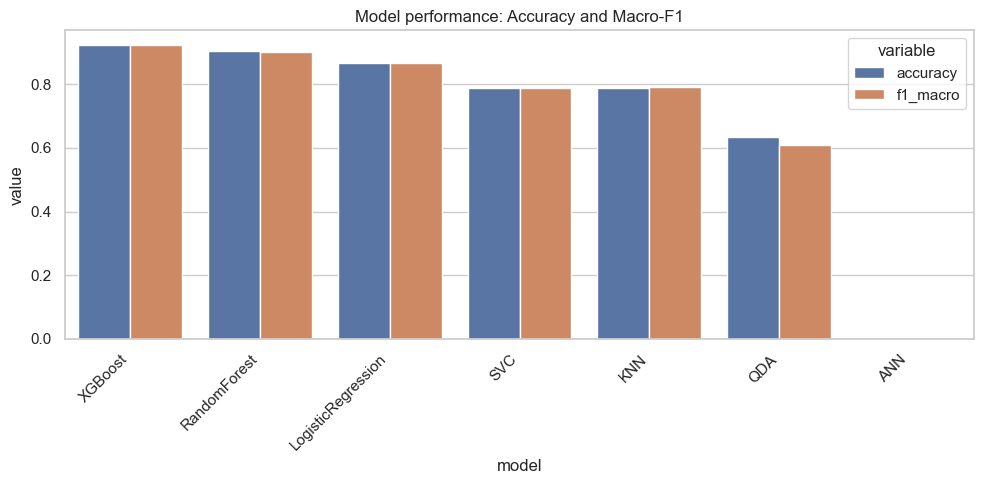

In [ ]:
# Performance summary (accuracy + macro-F1 if available)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# collect models
models = {}
for name, info in (results.items() if 'results' in globals() else {}):
    model = info['model'] if isinstance(info, dict) and 'model' in info else info
    models[name] = model

rows = []
for name, model in models.items():
    # choose test set
    X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
    y_test_use = globals().get('y_test')
    if X_test_use is None or y_test_use is None:
        continue
    try:
        y_pred = model.predict(X_test_use)
        acc = accuracy_score(y_test_use, y_pred)
        p = precision_score(y_test_use, y_pred, average='macro', zero_division=0)
        r = recall_score(y_test_use, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test_use, y_pred, average='macro', zero_division=0)
    except Exception:
        acc = np.nan; p = np.nan; r = np.nan; f1 = np.nan
    rows.append({'model': name, 'accuracy': acc, 'precision_macro': p, 'recall_macro': r, 'f1_macro': f1})

perf_df = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
display(perf_df)

# bar chart
plt.figure(figsize=(10,5))
sns.barplot(data=perf_df.melt(id_vars='model', value_vars=['accuracy','f1_macro']),
            x='model', y='value', hue='variable')
plt.xticks(rotation=45, ha='right')
plt.title('Model performance: Accuracy and Macro-F1')
plt.tight_layout()
plt.show()

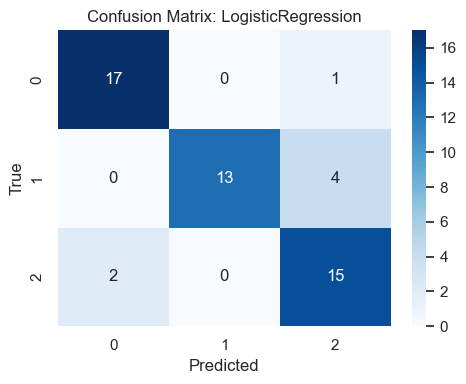

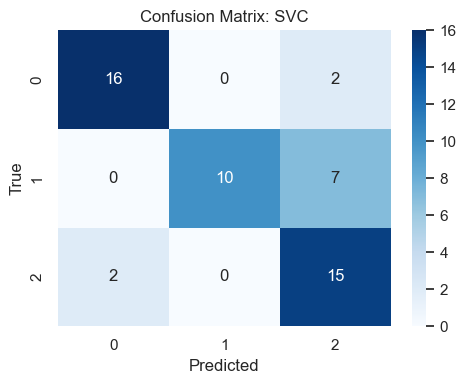

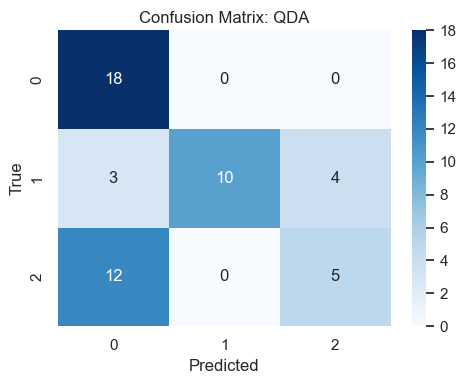

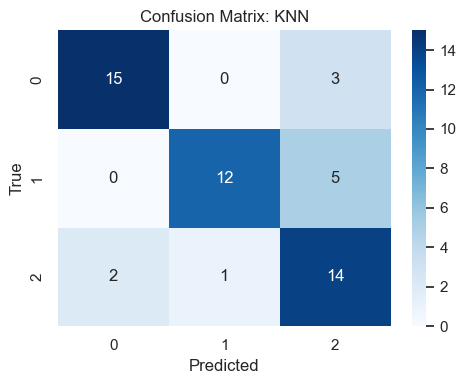

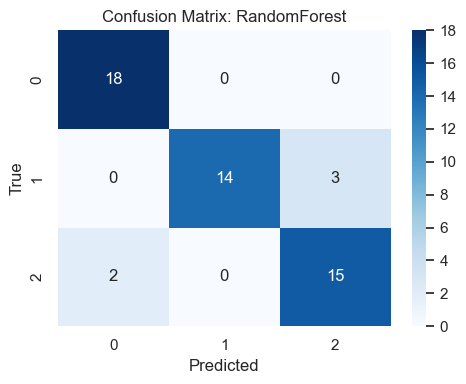

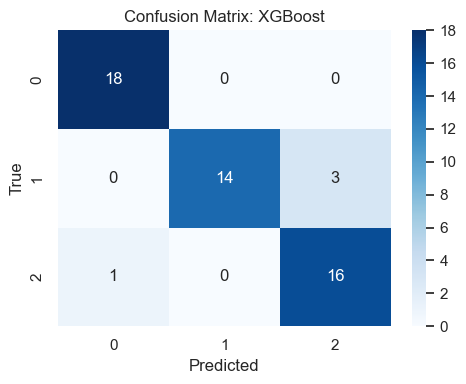

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Skipping ANN: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets


In [ ]:
# Confusion matrices
from sklearn.metrics import confusion_matrix
import numpy as np

X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    print("X_test / y_test not found in namespace.")
else:
    for name, model in models.items():
        try:
            y_pred = model.predict(X_test_use)
            cm = confusion_matrix(y_test_use, y_pred)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Confusion Matrix: {name}')
            plt.xlabel('Predicted'); plt.ylabel('True')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Skipping {name}: {e}")

In [48]:
# ROC & PR curves (multi-class micro-average). Requires predict_proba or decision_function.
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    print("X_test / y_test not found.")
else:
    classes = np.unique(y_test_use)
    y_bin = label_binarize(y_test_use, classes=classes)
    for name, model in models.items():
        try:
            if hasattr(model, 'predict_proba'):
                y_score = model.predict_proba(X_test_use)
            elif hasattr(model, 'decision_function'):
                y_score = model.decision_function(X_test_use)
            else:
                print(f"No prob/score for {name}, skipping ROC/PR.")
                continue
            # micro-average ROC
            fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})')
            plt.plot([0,1],[0,1],'k--', alpha=0.3)
            plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC (micro) - {name}')
            plt.legend(); plt.tight_layout(); plt.show()

            # PR curve (micro)
            precision, recall, _ = precision_recall_curve(y_bin.ravel(), y_score.ravel())
            ap = average_precision_score(y_bin, y_score, average='micro')
            plt.figure(figsize=(6,5))
            plt.plot(recall, precision, label=f'{name} (AP={ap:.2f})')
            plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(f'Precision-Recall (micro) - {name}')
            plt.legend(); plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Error plotting ROC/PR for {name}: {e}")

NameError: name 'models' is not defined

In [ ]:
# Learning curves per model (may be slow)
from sklearn.model_selection import learning_curve
X_train_use = globals().get('X_train_scaled', globals().get('X_train'))
y_train_use = globals().get('y_train')
if X_train_use is None or y_train_use is None:
    print("X_train / y_train not found.")
else:
    for name, model in models.items():
        try:
            train_sizes, train_scores, val_scores = learning_curve(model, X_train_use, y_train_use, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1,1.0,5), scoring='accuracy')
            plt.figure(figsize=(6,4))
            plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
            plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
            plt.title(f'Learning Curve: {name}')
            plt.xlabel('Training examples'); plt.ylabel('Accuracy'); plt.legend(); plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Learning curve failed for {name}: {e}")

NameError: name 'models' is not defined

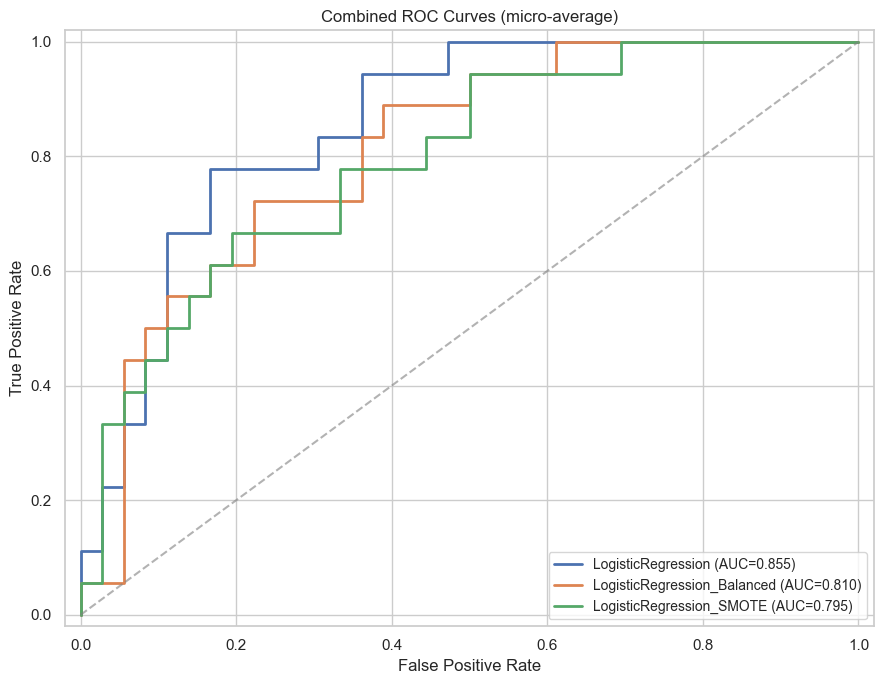

In [49]:
# Combined ROC curves (micro-average) for all models in `results`
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# collect models
models = {}
if 'results' in globals():
    for name, info in results.items():
        model = info['model'] if isinstance(info, dict) and 'model' in info else info
        models[name] = model
else:
    raise RuntimeError("`results` not found in namespace.")

# test data (prefer scaled if available)
X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    raise RuntimeError("`X_test` / `y_test` not found. Define them before running this cell.")

# binarize labels for multiclass micro-average
classes = np.unique(y_test_use)
y_bin = label_binarize(y_test_use, classes=classes)

plt.figure(figsize=(9,7))
sns.set_style("whitegrid")

for name, model in models.items():
    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_test_use)
        elif hasattr(model, 'decision_function'):
            y_score = model.decision_function(X_test_use)
            if y_score.ndim == 1:
                y_score = np.vstack([1 - y_score, y_score]).T
        else:
            print(f"Skipping {name}: no `predict_proba` or `decision_function`.")
            continue

        fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")
    except Exception as e:
        print(f"Error for {name}: {e}")

plt.plot([0,1], [0,1], linestyle='--', color='gray', alpha=0.6)
plt.xlim([-0.02,1.02]); plt.ylim([-0.02,1.02])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves (micro-average)')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

## Feature Important

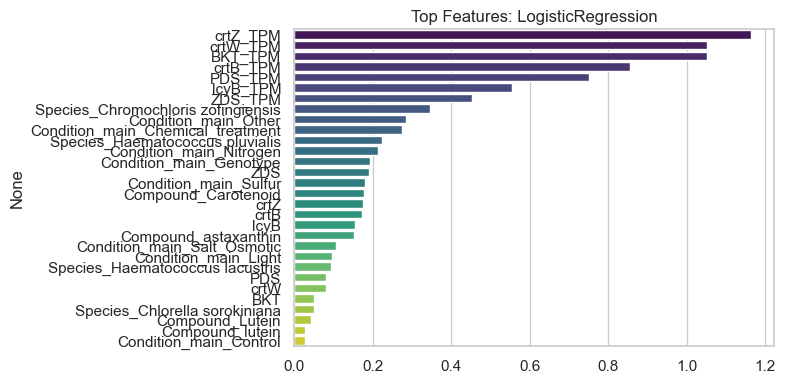

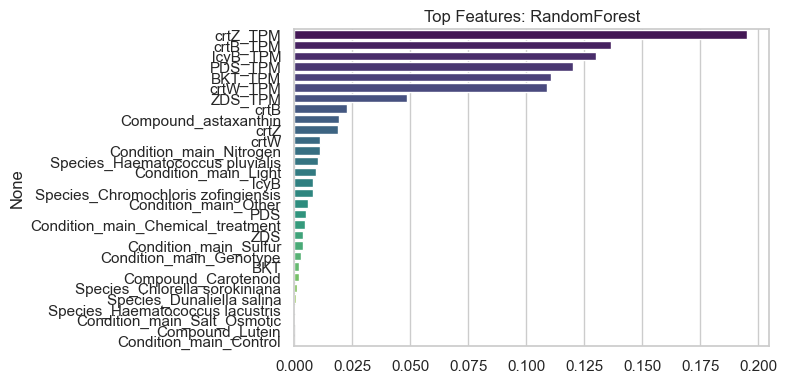

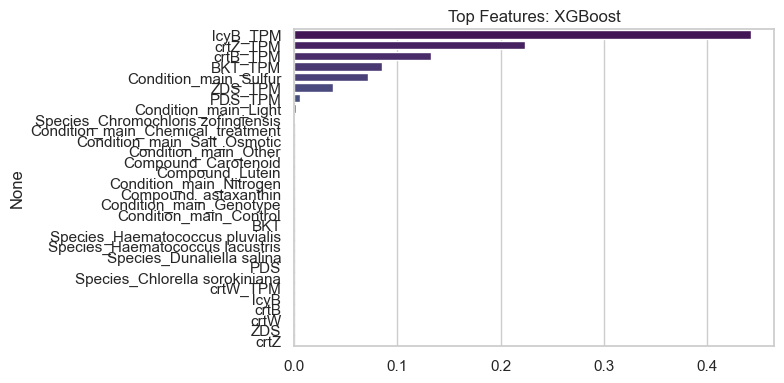

In [ ]:
# Feature importances
feature_names = None
if 'X_train' in globals() and hasattr(X_train, 'columns'):
    feature_names = X_train.columns
elif 'X_encoded' in globals() and hasattr(X_encoded, 'columns'):
    feature_names = X_encoded.columns

for name, model in models.items():
    try:
        if hasattr(model, 'feature_importances_'):
            imp = model.feature_importances_
        elif hasattr(model, 'coef_'):
            imp = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim>1 else np.abs(model.coef_)
        else:
            continue
        if feature_names is None:
            feature_names = [f'F{i}' for i in range(len(imp))]
        imp_df = pd.Series(imp, index=feature_names).sort_values(ascending=False).head(30)
        plt.figure(figsize=(8,4))
        sns.barplot(x=imp_df.values, y=imp_df.index, palette='viridis')
        plt.title(f'Top Features: {name}')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"Feature importances not available for {name}: {e}")

## Old model code

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dictionary to store models and their performance
imputation_models = {}

# 1. Logistic Regression
print("=" * 50)
print("Training Logistic Regression")
print("=" * 50)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr_scores = cross_val_score(lr, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {lr_scores}")
print(f"Mean CV Accuracy: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
lr.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['Logistic Regression'] = lr

# 2. K-Nearest Neighbors
print("\n" + "=" * 50)
print("Training K-Nearest Neighbors")
print("=" * 50)
knn = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {knn_scores}")
print(f"Mean CV Accuracy: {knn_scores.mean():.4f} (+/- {knn_scores.std():.4f})")
knn.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['KNN'] = knn

# 3. Random Forest
print("\n" + "=" * 50)
print("Training Random Forest")
print("=" * 50)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {rf_scores}")
print(f"Mean CV Accuracy: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
rf.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['Random Forest'] = rf

# 4. XGBoost
print("\n" + "=" * 50)
print("Training XGBoost")
print("=" * 50)
xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_scores = cross_val_score(xgb, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {xgb_scores}")
print(f"Mean CV Accuracy: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")
xgb.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['XGBoost'] = xgb

# Summary of model performance
print("\n" + "=" * 50)
print("Model Performance Summary")
print("=" * 50)
model_scores = {
    'Logistic Regression': lr_scores.mean(),
    'KNN': knn_scores.mean(),
    'Random Forest': rf_scores.mean(),
    'XGBoost': xgb_scores.mean()
}
for model_name, score in sorted(model_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name}: {score:.4f}")

Training Logistic Regression


NameError: name 'X_labeled_scaled' is not defined

#### Tune Logistic Regression

In [ ]:
print("=" * 60)
print("TUNING LOGISTIC REGRESSION")
print("=" * 60)

# Define hyperparameter grid
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse regularization strength
    'penalty': ['l2'],  # L2 regularization
    'solver': ['lbfgs', 'liblinear'],  # Solver algorithms
    'max_iter': [1000, 5000, 10000]
}

# GridSearchCV for exhaustive search
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nPerforming GridSearchCV for Logistic Regression...")
lr_grid.fit(X_labeled_scaled, y_labeled_encoded)

print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best CV Accuracy: {lr_grid.best_score_:.4f}")

# Get best model
lr_best = lr_grid.best_estimator_
lr_best_pred = lr_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, lr_best_pred):.4f}")

# Store best model
imputation_models['LR_tuned'] = lr_best
model_scores['LR_tuned'] = lr_grid.best_score_

TUNING LOGISTIC REGRESSION

Performing GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Accuracy: 0.6457
Training Accuracy: 0.6914


#### Tune K-Nearest Neighbors

In [ ]:
print("\n" + "=" * 60)
print("TUNING K-NEAREST NEIGHBORS")
print("=" * 60)

# Define hyperparameter grid
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Weight function
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # Algorithm
    'p': [1, 2]  # Minkowski distance power (1=Manhattan, 2=Euclidean)
}

# RandomizedSearchCV for faster tuning (KNN has many params)
knn_random = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nPerforming RandomizedSearchCV for KNN...")
knn_random.fit(X_labeled_scaled, y_labeled_encoded)

print(f"\nBest parameters: {knn_random.best_params_}")
print(f"Best CV Accuracy: {knn_random.best_score_:.4f}")

# Get best model
knn_best = knn_random.best_estimator_
knn_best_pred = knn_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, knn_best_pred):.4f}")

# Store best model
imputation_models['KNN_tuned'] = knn_best
model_scores['KNN_tuned'] = knn_random.best_score_


TUNING K-NEAREST NEIGHBORS

Performing RandomizedSearchCV for KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 15, 'algorithm': 'kd_tree'}
Best CV Accuracy: 0.5657
Training Accuracy: 0.7429


#### Tune Random Forest

In [ ]:
print("\n" + "=" * 60)
print("TUNING RANDOM FOREST")
print("=" * 60)

# Define hyperparameter grid
rf_params = {
    'n_estimators': [50, 100, 200, 300],  # Number of trees
    'max_depth': [5, 10, 15, 20, None],  # Max depth of trees
    'min_samples_split': [2, 5, 10, 20],  # Min samples to split
    'min_samples_leaf': [1, 2, 4, 8],  # Min samples in leaf
    'max_features': ['sqrt', 'log2'],  # Features per split
    'bootstrap': [True, False]  # Use bootstrap
}

# RandomizedSearchCV for efficiency
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nPerforming RandomizedSearchCV for Random Forest...")
rf_random.fit(X_labeled_scaled, y_labeled_encoded)

print(f"\nBest parameters: {rf_random.best_params_}")
print(f"Best CV Accuracy: {rf_random.best_score_:.4f}")

# Get best model
rf_best = rf_random.best_estimator_
rf_best_pred = rf_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, rf_best_pred):.4f}")

# Feature importance
print("\nFeature Importance (Top 10):")
feature_importance = pd.DataFrame({
    'Feature': X_labeled_encoded.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance.head(10))

# Store best model
imputation_models['RF_tuned'] = rf_best
model_scores['RF_tuned'] = rf_random.best_score_


TUNING RANDOM FOREST

Performing RandomizedSearchCV for Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}
Best CV Accuracy: 0.6571
Training Accuracy: 0.8514

Feature Importance (Top 10):
                              Feature  Importance
2                          TPM of BKT    0.263147
3                       TPM of CrtR-b    0.240393
6                Condition_main_Light    0.155678
1                              CrtR-b    0.076202
7              Condition_main_Light\n    0.055435
4   Condition_main_Chemical_treatment    0.044774
12                Compound_Carotenoid    0.034485
0                                 BKT    0.033425
14               Compound_astaxanthin    0.030727
8             Condition_main_Nitrogen    0.030054


#### Tune XGBoost

In [ ]:
print("\n" + "=" * 60)
print("TUNING XGBOOST")
print("=" * 60)

# Two-stage tuning for XGBoost (recommended approach)
# Stage 1: Tune tree-specific parameters
xgb_params_1 = {
    'max_depth': [3, 5, 7, 9],  # Tree depth
    'min_child_weight': [1, 3, 5, 7],  # Min child weight
    'subsample': [0.6, 0.8, 1.0],  # Row sampling
    'colsample_bytree': [0.6, 0.8, 1.0]  # Column sampling
}

print("\nStage 1: Tuning tree parameters...")
xgb_random_1 = RandomizedSearchCV(
    XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
    xgb_params_1,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random_1.fit(X_labeled_scaled, y_labeled_encoded)
print(f"Best tree parameters: {xgb_random_1.best_params_}")
print(f"Best CV Accuracy: {xgb_random_1.best_score_:.4f}")

# Stage 2: Tune boosting parameters with best tree params
best_tree_params = xgb_random_1.best_params_

xgb_params_2 = {
    'n_estimators': [100, 200, 300, 500],  # Number of boosting rounds
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],  # Learning rate
    'gamma': [0, 0.1, 0.5, 1.0]  # Min loss reduction
}

print("\nStage 2: Tuning boosting parameters...")
xgb_random_2 = RandomizedSearchCV(
    XGBClassifier(
        max_depth=best_tree_params['max_depth'],
        min_child_weight=best_tree_params['min_child_weight'],
        subsample=best_tree_params['subsample'],
        colsample_bytree=best_tree_params['colsample_bytree'],
        random_state=42,
        eval_metric='mlogloss'
    ),
    xgb_params_2,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random_2.fit(X_labeled_scaled, y_labeled_encoded)
print(f"\nBest boosting parameters: {xgb_random_2.best_params_}")
print(f"Best CV Accuracy: {xgb_random_2.best_score_:.4f}")

# Get best XGBoost model
xgb_best = xgb_random_2.best_estimator_
xgb_best_pred = xgb_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, xgb_best_pred):.4f}")

# Feature importance
print("\nFeature Importance (Top 10):")
xgb_importance = pd.DataFrame({
    'Feature': X_labeled_encoded.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)
print(xgb_importance.head(10))

# Store best model
imputation_models['XGB_tuned'] = xgb_best
model_scores['XGB_tuned'] = xgb_random_2.best_score_


TUNING XGBOOST

Stage 1: Tuning tree parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best tree parameters: {'subsample': 0.6, 'min_child_weight': 3, 'max_depth': 7, 'colsample_bytree': 0.6}
Best CV Accuracy: 0.6629

Stage 2: Tuning boosting parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best boosting parameters: {'n_estimators': 100, 'learning_rate': 0.01, 'gamma': 0}
Best CV Accuracy: 0.6514
Training Accuracy: 0.8229

Feature Importance (Top 10):
                              Feature  Importance
6                Condition_main_Light    0.211254
2                          TPM of BKT    0.118518
12                Compound_Carotenoid    0.108747
3                       TPM of CrtR-b    0.096739
1                              CrtR-b    0.094204
0                                 BKT    0.094063
4   Condition_main_Chemical_treatment    0.077700
14               Compound_astaxanthin    0.072615
7              Condition_main_Light\n  

In [ ]:
# make Series so pandas aligns by model name
original_sr = pd.Series(original_scores)
tuned_sr = pd.Series(tuned_scores)

comparison_df = pd.concat([original_sr, tuned_sr], axis=1)
comparison_df.columns = ['Original', 'Tuned']

comparison_df['Improvement'] = comparison_df['Tuned'] - comparison_df['Original']
comparison_df['Improvement %'] = (comparison_df['Improvement'] /
                                  comparison_df['Original'].replace(0, np.nan) * 100).fillna(0)

print(comparison_df)
print(f"\nBest Original Model: {max(original_scores, key=original_scores.get)} ({max(original_scores.values()):.4f})")
print(f"Best Tuned Model: {max(tuned_scores, key=tuned_scores.get)} ({max(tuned_scores.values()):.4f})")

                     Original     Tuned  Improvement  Improvement %
Logistic Regression  0.497143  0.645714     0.148571      29.885057
KNN                  0.508571  0.565714     0.057143      11.235955
Random Forest        0.571429  0.657143     0.085714      15.000000
XGBoost              0.542857  0.651429     0.108571      20.000000

Best Original Model: Random Forest (0.5714)
Best Tuned Model: Random Forest (0.6571)


In [ ]:
# Use the best model (choose the one with highest CV score)
best_model_name = max(model_scores, key=model_scores.get)
best_model = imputation_models[best_model_name]

print(f"Using {best_model_name} for imputation (Accuracy: {model_scores[best_model_name]:.4f})")

# Predict missing labels
y_unlabeled_predicted_encoded = best_model.predict(X_unlabeled_scaled)

# Decode predictions back to original label names
y_unlabeled_predicted = label_encoder.inverse_transform(y_unlabeled_predicted_encoded)

print(f"\nPredicted labels for missing values:")
print(f"Distribution of imputed labels:")
unique, counts = np.unique(y_unlabeled_predicted, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count}")

Using RF_tuned for imputation (Accuracy: 0.6571)

Predicted labels for missing values:
Distribution of imputed labels:
  High: 1
  Low: 44


Label distribution comparison:

Before imputation (labeled data only):
Label
Low       0.371429
Medium    0.314286
High      0.314286
Name: proportion, dtype: float64

After imputation (full dataset):
Label
Low       0.495455
High      0.254545
Medium    0.250000
Name: proportion, dtype: float64


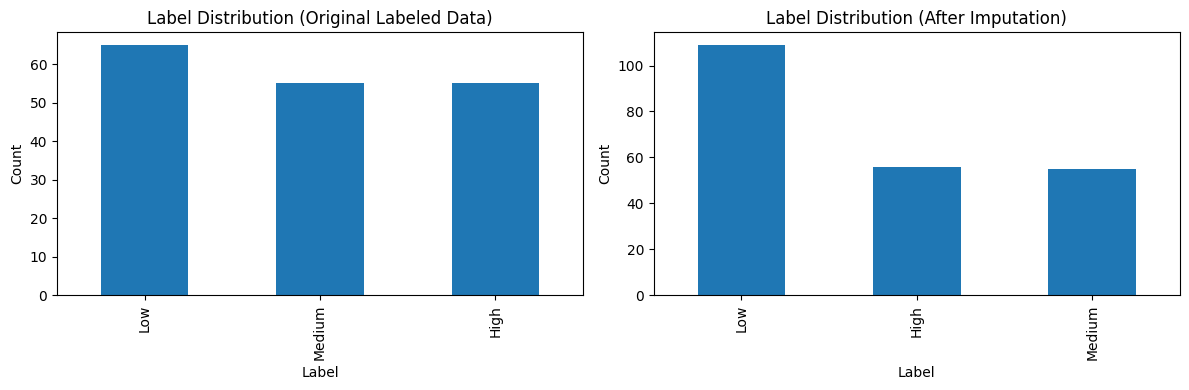

In [ ]:
# Compare distributions before and after
print("Label distribution comparison:")
print("\nBefore imputation (labeled data only):")
print(labeled_df['Label'].value_counts(normalize=True))
print("\nAfter imputation (full dataset):")
print(df_imputed['Label'].value_counts(normalize=True))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original labeled data
labeled_df['Label'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Label Distribution (Original Labeled Data)')
axes[0].set_ylabel('Count')

# After imputation
df_imputed['Label'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Label Distribution (After Imputation)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
df_imputed.shape

(220, 10)

In [ ]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 0 to 223
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Species         220 non-null    object 
 1   Strain          202 non-null    object 
 2   Bioproject      220 non-null    object 
 3   Condition_main  220 non-null    object 
 4   Compound        220 non-null    object 
 5   Label           220 non-null    object 
 6   BKT             220 non-null    float64
 7   CrtR-b          220 non-null    float64
 8   TPM of BKT      220 non-null    float64
 9   TPM of CrtR-b   220 non-null    float64
dtypes: float64(4), object(6)
memory usage: 27.0+ KB


In [ ]:
target_col = 'Label'
cols_to_drop = ['Species', 'Strain', 'Bioproject']  # drop identifiers/non-features

In [ ]:
X = df_imputed.drop(columns=cols_to_drop + [target_col])
y = df_imputed[target_col]

In [ ]:
# encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# one-hot encode categorical features (same approach as before)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [ ]:
#Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
#Fearure Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")

X_train shape: (140, 15), X_test shape: (35, 15)


In [ ]:
#Collect Models results
results = {}